In [120]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import time

import astropy.units as u
import astropy.cosmology.units as cu
import astropy.constants as const

import raytrace

rng = np.random.default_rng()

colors = ['red', 'orangered','yellowgreen', 'royalblue', 'blueviolet']
cm_kpc = u.cm.to(u.kpc)
cm_kpc


with h5py.File("outputs/tng_cluster_catalog.hdf5", "a") as f:
    print(f['table'].keys())
    halo_ids = f['table/haloID'][:]
    halo_pos = f['table/GroupPos'][:] - f['table/GroupCM'][:]
    # print(ids)
    for weight in ('mstar', 'sfr'):
        trace = f[f'trace_{weight}']
        dm_far_mean = f.require_dataset(f'table/dm_{weight}_far_mean', shape=halo_ids.shape, dtype='f8')
        dm_far_std = f.require_dataset(f'table/dm_{weight}_far_std', shape=halo_ids.shape, dtype='f8')
        dm_far_aligned_mean = f.require_dataset(f'table/dm_{weight}_far_aligned_mean', shape=halo_ids.shape, dtype='f8')
        dm_far_aligned_std = f.require_dataset(f'table/dm_{weight}_far_aligned_std', shape=halo_ids.shape, dtype='f8')
    
        # print(f['subhalos'].keys())
        # print(f['table'].keys())
        # print(trace['halo_10293151'].keys())
        for (i, halo_id) in enumerate(halo_ids):
            path = f'halo_{halo_id}'
            
            if path not in trace: 
                dm_far_mean[i] = np.nan
                dm_far_std[i] = np.nan
                dm_far_aligned_mean[i] = np.nan
                dm_far_aligned_std[i] = np.nan
                continue
                
            print(trace[f'halo_{halo_id}'])

            cosine = (lambda a, b: np.sum(a*b, axis=1) / np.linalg.norm(a, axis=1) / np.linalg.norm(b, axis=1))(
                trace[path]['star_pos'][:] - halo_pos[i], trace[path]['direction'][:]
            )

            dm = trace[path]['dm_voronoi']
            dm_near = dm[:, -1,  1] * (cm_kpc**3) * 1000
            dm_far  = dm[:, -1, -1] * (cm_kpc**3) * 1000 - dm_near
    
            dm_far_mean[i] = np.mean(dm_far)
            dm_far_std[i] = np.std(dm_far)
            
            dm_far_aligned_mean[i] = np.mean(dm_far[cosine > 0.9])
            dm_far_aligned_std[i] = np.std(dm_far[cosine > 0.9])
    
        # print(dm_far_mean[:])

<KeysViewHDF5 ['Bmag_uG_10kpc', 'GroupBHMass', 'GroupBHMdot', 'GroupCM', 'GroupContaminationFracByMass', 'GroupContaminationFracByNumPart', 'GroupFirstSub', 'GroupGasMetalFractions', 'GroupGasMetallicity', 'GroupLen', 'GroupLenType', 'GroupMass', 'GroupMassType', 'GroupNsubs', 'GroupOffsetType', 'GroupOrigHaloID', 'GroupPos', 'GroupPrimaryZoomTarget', 'GroupSFR', 'GroupStarMetalFractions', 'GroupStarMetallicity', 'GroupVel', 'GroupWindMass', 'Group_Fe_Crit200', 'Group_Fe_Crit500', 'Group_Fgas_Crit200', 'Group_Fgas_Crit500', 'Group_Fgas_Crit500_max', 'Group_M_Crit200', 'Group_M_Crit500', 'Group_M_Mean200', 'Group_M_TopHat200', 'Group_R_Crit200', 'Group_R_Crit500', 'Group_R_Mean200', 'Group_R_TopHat200', 'Header', 'InfoID', 'InfoType', 'SimulationName', 'SnapshotNumber', 'TracerLengthType', 'TracerOffsetType', 'coolcore_C_phys', 'coolcore_C_scaled', 'coolcore_entropy', 'coolcore_flag', 'coolcore_ne', 'coolcore_ne_slope', 'coolcore_tcool', 'dm_mstar_far_aligned_mean', 'dm_mstar_far_aligne

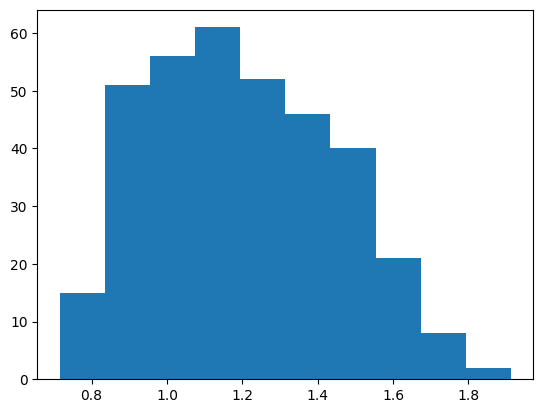

In [73]:
with h5py.File("outputs/tng_cluster_catalog.hdf5", "r") as f:
    plt.hist(f['table/r500c'])

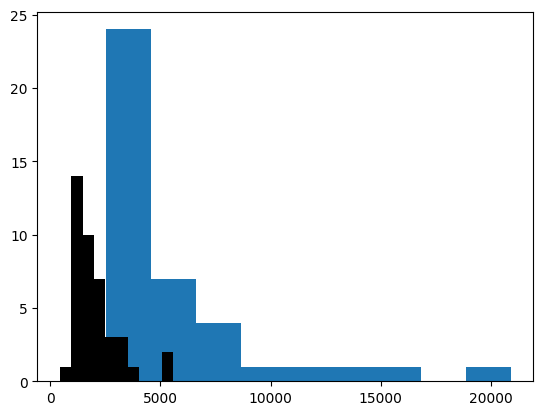

In [83]:
with h5py.File("outputs/tng_cluster_catalog.hdf5", "r") as f:
    plt.hist(f['table/dm_mstar_far_aligned_mean'])
    plt.hist(f['table/dm_mstar_far_mean'], color='black')

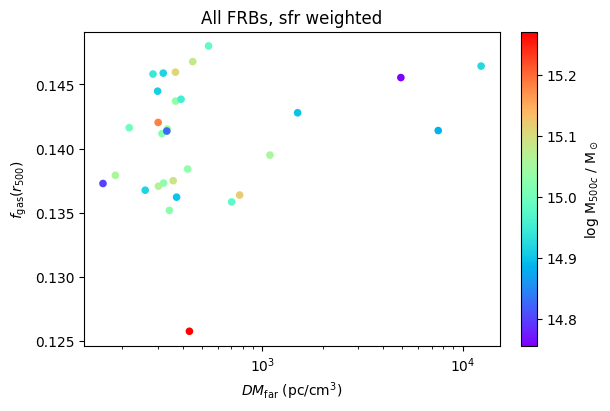

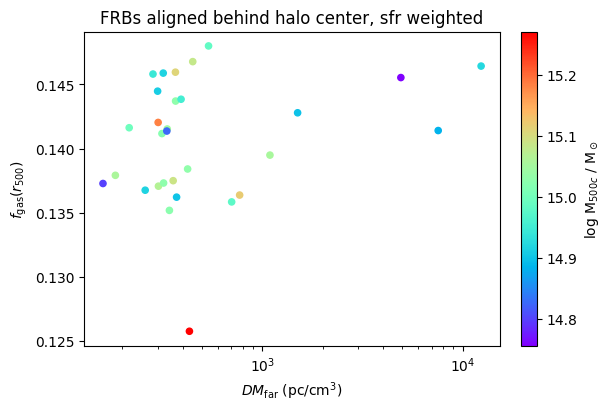

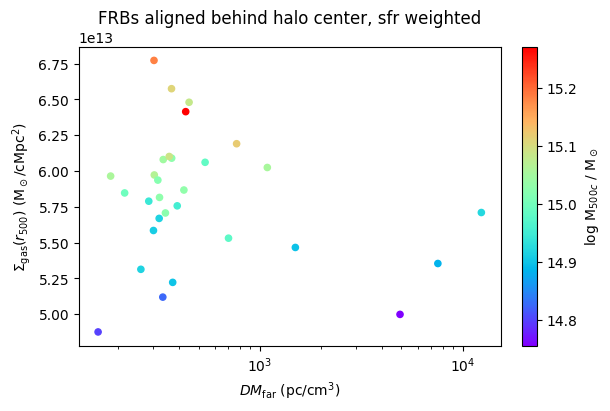

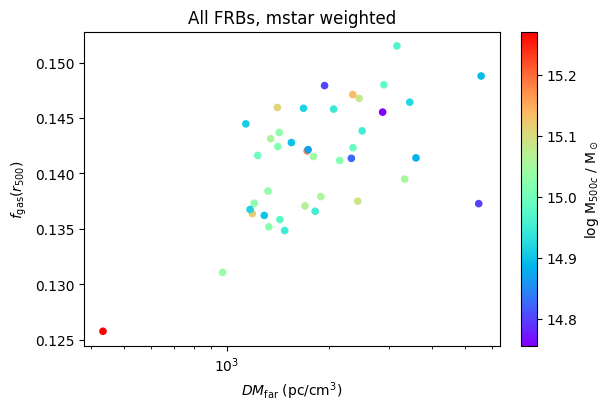

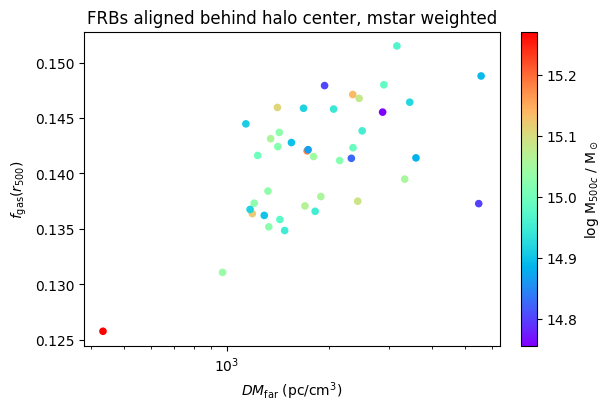

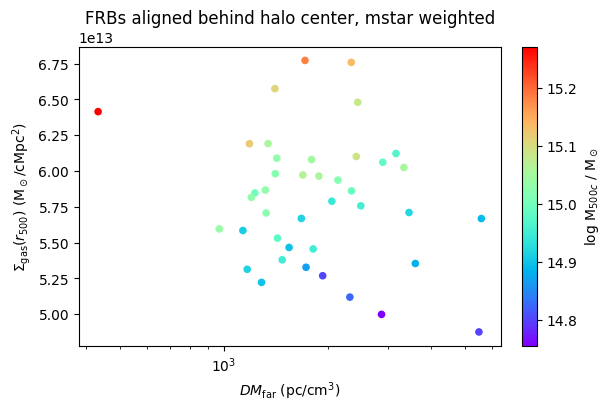

In [121]:
with h5py.File("outputs/tng_cluster_catalog.hdf5", "r") as f:
    for weight in ('sfr', 'mstar'):
        plt.figure(figsize=(6,4), constrained_layout=True)
        # print(f['table'].keys())
    
        x = f[f'table/dm_{weight}_far_mean'][:]      # x-axis
        y = f['table/fgas_r500'][:] # y-axis
        c = f['table/mhalo_500c'][:]             # color by mass (m500c)
    
        mask = (x > 0) & (y > 0)
        sc = plt.scatter(x[mask], y[mask], c=c[mask], s=20, cmap='rainbow')
    
        plt.xscale('log')
        plt.colorbar(sc, label='log M$_{500c}$ / M$_\odot$')
        plt.xlabel(r'$DM_{\rm far}$ (pc/cm$^3$)')
        plt.ylabel(r'$f_{\rm gas}(r_{500})$')
        plt.title(f'All FRBs, {weight} weighted')
        plt.show()
    
        plt.figure(figsize=(6,4), constrained_layout=True)
        x = f[f'table/dm_{weight}_far_mean'][:]      # x-axis
        y = f['table/fgas_r500'][:] # y-axis
        c = f['table/mhalo_500c'][:]             # color by mass (m500c)
    
        mask = (x > 0) & (y > 0)
        sc = plt.scatter(x[mask], y[mask], c=c[mask], s=20, cmap='rainbow')
    
        plt.xscale('log')
        plt.colorbar(sc, label='log M$_{500c}$ / M$_\odot$')
        plt.xlabel(r'$DM_{\rm far}$ (pc/cm$^3$)')
        plt.ylabel(r'$f_{\rm gas}(r_{500})$')
        plt.title(f'FRBs aligned behind halo center, {weight} weighted')
        plt.show()

        plt.figure(figsize=(6,4), constrained_layout=True)
        x = f[f'table/dm_{weight}_far_mean'][:]      # x-axis
        y = f['table/fgas_r500'][:] * (10**f['table/mhalo_500c'][:]) / (f['table/r500c'][:]**2) # y-axis
        c = f['table/mhalo_500c'][:]             # color by mass (m500c)
    
        mask = (x > 0) & (y > 0)
        sc = plt.scatter(x[mask], y[mask], c=c[mask], s=20, cmap='rainbow')
    
        plt.xscale('log')
        plt.colorbar(sc, label='log M$_{500c}$ / M$_\odot$')
        plt.xlabel(r'$DM_{\rm far}$ (pc/cm$^3$)')
        plt.ylabel(r'$\Sigma_{\rm gas}(r_{500})$ (M$_\odot$/cMpc$^2$)')
        plt.title(f'FRBs aligned behind halo center, {weight} weighted')
        plt.show()